# LEAR — Lasso Estimated AutoRegressive Model

- Part A: Regularisation parameter `ALPHA` sensitivity - 4-window averaging scheme
- Part B: Window scheme comparison - 4-window averaging vs single expanding window

**Standardisation**  
Within each training window, the data will be standardized using the window's mean and standard deviation. These parameters will be used to standardize the test data prior to making predictions.

**Hyperparameter starting point**  
The starting value of the smoothing parameter `ALPHA` will be 0.0034, and the four window sizes will be [100, 84, 56, 28] days- the same parameters used by Lebedev et al. (2026) for hourly data from Germany. Part A will determine whether this value of `ALPHA` is appropriate for quarter-hourly data
The best value of `ALPHA` found in Part A will be used for all analyses in Part B

# Step 1 - Imports

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from sklearn.linear_model import Lasso

print("Imports OK")

Imports OK


# Step 2 - Configuration

In [47]:
split_dir  = Path("../data/split")
output_dir = Path("../data/results")

nintervals = 96

#maximum number of optimization iterations allowed for the LASSO solver
#increasing it to 10000 gives the algorithm enough time to converge
lasso_max_iter = 10000

features = [
    "price_lag1d",
    "price_lag7d",
    "price_hourly_lag1d",
    "price_hourly_lag7d",
    "wind_mwh",
    "solar_mwh",
    "load_mwh",
]
target  = "price_eur_mwh"

# four training windows (days), adapted from Lebedev et al. (2026)
windows = [100, 84, 56, 28]

# define the candidate LASSO regularisation values
# alpha values for the regularisation sensitivity analysis
# alpha controls how strongly coefficients are penalized
# larger alpha values shrink more coefficients towards zero
alphas = [0.001, 0.0034079864342526534, 0.01, 0.1]

print(f"Windows : {windows} days")
print(f"Alphas  : {alphas}")

Windows : [100, 84, 56, 28] days
Alphas  : [0.001, 0.0034079864342526534, 0.01, 0.1]


# Step 3 - Laod Data

In [48]:
df = pd.read_csv(split_dir / "feature_matrix_clean.csv", parse_dates=["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

train_days = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "train_days.csv")["date"]]
test_days  = [pd.Timestamp(d).date() for d in pd.read_csv(split_dir / "test_days.csv")["date"]]
all_days   = sorted(df["timestamp"].dt.date.unique())

n_train = len(train_days)   # 100
n_test  = len(test_days)    # 44
n_total = len(all_days)     # 144

X_all = df[features].values   # (13824, 7)
y_all = df[target].values     # (13824,)

# ground-truth prices for the test period in EUR/MWh
train_end  = n_train * nintervals
y_test_orig = y_all[train_end:].reshape(n_test, nintervals)

print(f"X_all : {X_all.shape}")
print(f"Train : {n_train} days - Test : {n_test} days  - Total : {n_total} days")

X_all : (13824, 7)
Train : 100 days - Test : 44 days  - Total : 144 days


# Step 4 - Helper: standardize and fit one window

A single function encapsulates standardization and LASSO fitting for one training window.
Scaling is computed from that window's training data only, then applied to the test row.
The prediction is back-transformed to EUR/MWh

In [49]:
#Parameters:
#X_all -> full feature array (n_total_obs, n_features)
#y_all -> full target array  (n_total_obs,)
#row_start ->  first row of the training window
#row_end -> one past the last row of the training window (= first row of the test observation)
#row_pred -> first row of the 96 test observations to predict
#alpha -> LASSO regularisation parameter λ
#Returns: pred_orig: predicted prices in EUR/MWh, shape (nintervals,)

def fit_and_predict(X_all, y_all, row_start, row_end, row_pred, alpha, max_iter=lasso_max_iter , nintervals=nintervals):
    # training slice for this window
    X_tr = X_all[row_start:row_end, :]
    y_tr = y_all[row_start:row_end]

    # compute scaling statistics from this window's training data only
    mean_X = X_tr.mean(axis=0)
    std_X  = X_tr.std(axis=0)
    std_X[std_X == 0] = 1.0          # to avoid division by zero for constant features

    mean_y = y_tr.mean()
    std_y  = y_tr.std()
    if std_y == 0:
        std_y = 1.0

    # standardize training data
    X_tr_sc = (X_tr - mean_X) / std_X
    y_tr_sc = (y_tr - mean_y) / std_y

    # apply the same scaling to the test row
    X_te_sc = (X_all[row_pred:row_pred + nintervals, :] - mean_X) / std_X

    # Initializes a Lasso model, which uses 'alpha' to penalize and remove less important features
    reg = Lasso(alpha=alpha, max_iter=max_iter, fit_intercept=True)
    reg.fit(X_tr_sc, y_tr_sc)
    pred_sc = reg.predict(X_te_sc)
    
    # back-transform prediction to EUR/MWh
    return pred_sc * std_y + mean_y


print("Helper function defined")

Helper function defined


# Step 5 - Part A: Alpha Comparison (4-Window Averaging)

For each value of alpha, four LEAR models are estimated per test day using windows of 100, 84, 56, and 28 days. The final forecast is the unweighted average of the four window predictions. Each window uses its own standardization parameters.

In [50]:
alpha_results = {}   #stores the evaluation scores
alpha_preds   = {}   #stores forecast matrix

for alpha_val in alphas:
    alpha_name = f"alpha_{alpha_val}"
    print(f"\n{alpha_name}")

    #ceates an empty matrix to collect predictions for all test days
    all_preds = np.zeros((n_test, nintervals))


   #loop over all test days
    for i in range(n_test):
        forecast_day_idx = n_train + i            # absolute day index of the day being forecast
        row_pred = forecast_day_idx * nintervals  # first row of the 96 test observations

        #loop over the 4 training windows
        window_preds = []                    # one prediction array per window
        for w in windows:
            row_end   = forecast_day_idx * nintervals              #the first row of the forecast day
            row_start = max(forecast_day_idx - w, 0) * nintervals  #the first row of this training window

            #fit model and predict
            pred = fit_and_predict(
                X_all, y_all,
                row_start=row_start,
                row_end=row_end,
                row_pred=row_pred,
                alpha=alpha_val,
            )
            window_preds.append(pred)

        # unweighted average across the four windows
        all_preds[i, :] = np.mean(window_preds, axis=0)

     # MAE: average absolute error; RMSE: penalises large errors more heavily
    errors = y_test_orig - all_preds
    mae  = float(np.mean(np.abs(errors)))
    rmse = float(np.sqrt(np.mean(errors ** 2)))

    #store results
    alpha_results[alpha_name] = {"MAE": round(mae, 4), "RMSE": round(rmse, 4)}
    alpha_preds[alpha_name]   = all_preds
    print(f"  -> MAE: {mae:.4f}  RMSE: {rmse:.4f} EUR/MWh")

print("\nAll lambda configurations done")


alpha_0.001
  -> MAE: 12.1721  RMSE: 16.1516 EUR/MWh

alpha_0.0034079864342526534
  -> MAE: 12.1401  RMSE: 16.1288 EUR/MWh

alpha_0.01
  -> MAE: 12.0580  RMSE: 16.0843 EUR/MWh

alpha_0.1
  -> MAE: 12.7965  RMSE: 18.2178 EUR/MWh

All lambda configurations done


# Step 6 - Regularisation comparison table

In [51]:
print("LEAR — Regularisation Parameter Comparison (4-window averaging)")
print(f"  {'Configuration':<44} {'MAE':>8} {'RMSE':>8}")
for name, r in alpha_results.items():
    print(f"  {name:<44} {r['MAE']:>8.4f} {r['RMSE']:>8.4f}")
print()

#find the alpha configuration with the lowest MAE
best_alpha = min(alpha_results, key=lambda x: alpha_results[x]["MAE"])

print(f"\nBest lambda (lowest MAE): {best_alpha}")
print(f"Best lambda value: {best_alpha_val}")

LEAR — Regularisation Parameter Comparison (4-window averaging)
  Configuration                                     MAE     RMSE
  alpha_0.001                                   12.1721  16.1516
  alpha_0.0034079864342526534                   12.1401  16.1288
  alpha_0.01                                    12.0580  16.0843
  alpha_0.1                                     12.7965  18.2178


Best lambda (lowest MAE): alpha_0.01
Best lambda value: 0.01


# Step 7 - Part B: Expanding Window (Best Alpha)

The 4-window averaging scheme is compared against a single expanding window, using the best `ALPHA` found in Part A for both. 
The expanding window uses all available training data at each forecast origin.
Standardisation is recomputed from that full expanding window.

In [52]:
#use the best-performing LASSO regularisation value from the alpha comparison
print(f"Using best alpha: {best_alpha_val}")
print(f"Running expanding window evaluation ({n_test} test days)")

#create an empty matrix to store the expanding-window predictions
pred_expanding = np.zeros((n_test, nintervals))

#loop over all test days
for i in range(n_test):
    forecast_day_idx = n_train + i                # index of the day being forecast
    row_end  = forecast_day_idx * nintervals      # expanding window always starts at row 0
    row_pred = forecast_day_idx * nintervals

    pred_expanding[i, :] = fit_and_predict(
        X_all, y_all,
        row_start=0,
        row_end=row_end,
        row_pred=row_pred,
        alpha=best_alpha_val,
    )

    # print progress for the first forecast day and then every 10 days
    if (i + 1) % 10 == 0 or i == 0: print(f"  Day {i+1:>2d}/44 - trained on {forecast_day_idx} days ({row_end} observations)")

#compute evaluation metrics
errors_exp = y_test_orig - pred_expanding
mae_exp  = float(np.mean(np.abs(errors_exp)))
rmse_exp = float(np.sqrt(np.mean(errors_exp ** 2)))

print(f"\nExpanding window -> MAE: {mae_exp:.4f}  RMSE: {rmse_exp:.4f} EUR/MWh")

Using best alpha: 0.01
Running expanding window evaluation (44 test days)
  Day  1/44 - trained on 100 days (9600 observations)
  Day 10/44 - trained on 109 days (10464 observations)
  Day 20/44 - trained on 119 days (11424 observations)
  Day 30/44 - trained on 129 days (12384 observations)
  Day 40/44 - trained on 139 days (13344 observations)

Expanding window -> MAE: 12.0746  RMSE: 16.1635 EUR/MWh


# Step 8 - Window Scheme Comparison

In [53]:
best_4w = alpha_results[best_alpha]

print("LEAR — Window Scheme Comparison (using {best_alpha})")
print(f"{'Scheme':<30} {'MAE':>8} {'RMSE':>8}")
print(f"{'4-window averaging':<30} {best_4w['MAE']:>8.4f} {best_4w['RMSE']:>8.4f}")
print(f"{'Expanding window':<30} {mae_exp:>8.4f} {rmse_exp:>8.4f}")

LEAR — Window Scheme Comparison (using {best_alpha})
Scheme                              MAE     RMSE
4-window averaging              12.0580  16.0843
Expanding window                12.0746  16.1635


# Step 9 - Forecast Plot (Best Configuration)
Actual vs forecast prices for the first 7 days of the evaluation period (16–22 January 2026), using the best ALPHA with 4-window averaging

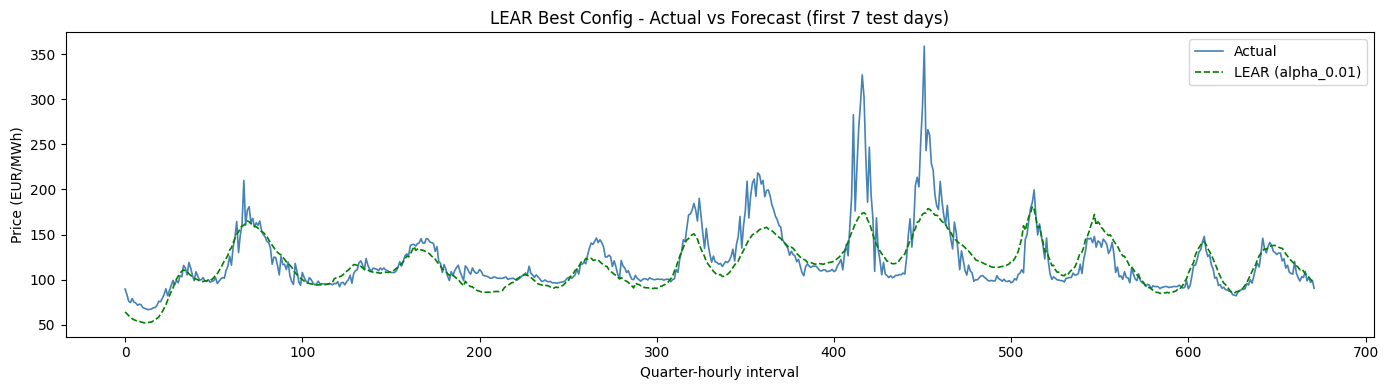

Plot saved


In [54]:
best_pred = alpha_preds[best_alpha]
n_plot    = 7 * nintervals

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(y_test_orig.flatten()[:n_plot], label="Actual", linewidth=1.2, color="steelblue")
ax.plot(best_pred.flatten()[:n_plot], label=f"LEAR ({best_alpha})", linewidth=1.2, color="green", linestyle="--")
ax.set_title("LEAR Best Config - Actual vs Forecast (first 7 test days)")
ax.set_xlabel("Quarter-hourly interval")
ax.set_ylabel("Price (EUR/MWh)")
ax.legend()
plt.tight_layout()
plt.savefig(output_dir / "LEAR_forecast_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved")

# Step 10 - Save Results

In [55]:
best_result = alpha_results[best_alpha]

lear_dict = {
    # identification
    "model_name"       : "LEAR",
    # best configuration — 4-window, best lambda by MAE
    "best_alpha"       : best_alpha,
    "best_alpha_val"   : best_alpha_val,
    "all_alpha_results": alpha_results,
    "prediction"       : best_pred,       # (n_test, 96) EUR/MWh, 4-window best
    "mae"              : best_result["MAE"],
    "rmse"             : best_result["RMSE"],
    # window scheme comparison (both use best lambda)
    "pred_expanding"   : pred_expanding,  # (n_test, 96) EUR/MWh
    "mae_expanding"    : mae_exp,
    "rmse_expanding"   : rmse_exp,
    # ground truth and metadata
    "y_test"           : y_test_orig,     # (n_test, 96) EUR/MWh
    "test_days"        : [str(d) for d in test_days],
}

with open(output_dir / "LEAR.pkl", "wb") as f: pickle.dump([lear_dict], f)

print(f"Saved: {output_dir / 'LEAR.pkl'}")
print("LEAR.ipynb complete")

Saved: ..\data\results\LEAR.pkl
LEAR.ipynb complete
